In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("Loading dataset... this may take a minute.")
# Load the Excel file directly
df = pd.read_excel('Online Retail.xlsx')

print("Raw Data Shape:", df.shape)
display(df.head())

Loading dataset... this may take a minute.
Raw Data Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# 1. Drop rows with missing Customer IDs (usually guest checkouts or system errors)
df = df.dropna(subset=['CustomerID'])

# 2. Filter out canceled orders (Quantity < 0) and bad debt adjustments (UnitPrice <= 0)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 3. Calculate total revenue for each line item (Quantity * Price)
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

# 4. Extract just the Date from the InvoiceDate timestamp
df['Date'] = df['InvoiceDate'].dt.date

print("Cleaned Data Shape:", df.shape)
display(df[['InvoiceNo', 'Date', 'Quantity', 'Total_Sales']].head())

Cleaned Data Shape: (397884, 10)


,InvoiceNo,Date,Quantity,Total_Sales
0,536365,2010-12-01,6,15.30
1,536365,2010-12-01,6,20.34
2,536365,2010-12-01,8,22.00
3,536365,2010-12-01,6,20.34
4,536365,2010-12-01,6,20.34


In [3]:
# Group by Date to get the total daily revenue
daily_sales = df.groupby('Date')['Total_Sales'].sum().reset_index()

# Convert Date column back to a datetime object for feature extraction
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

# Create time-based features for the Machine Learning model
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['DayOfMonth'] = daily_sales['Date'].dt.day

# Add a 7-day rolling average (Highly recommended for smoothing retail noise)
daily_sales['7_Day_Avg'] = daily_sales['Total_Sales'].rolling(window=7).mean()
daily_sales = daily_sales.dropna() # Drop the first 6 days which won't have a rolling average

# Define our inputs (X) and what we want to predict (y)
X = daily_sales[['Year', 'Month', 'DayOfWeek', 'DayOfMonth', '7_Day_Avg']]
y = daily_sales['Total_Sales']

In [4]:
# Chronological split: Train on the first 80% of the year, predict the final 20%
split_index = int(len(daily_sales) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
dates_train = daily_sales['Date'].iloc[:split_index]
dates_test = daily_sales['Date'].iloc[split_index:]

# Train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the future sales
predictions = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: £{mae:.2f} per day")

Mean Absolute Error: £13543.34 per day


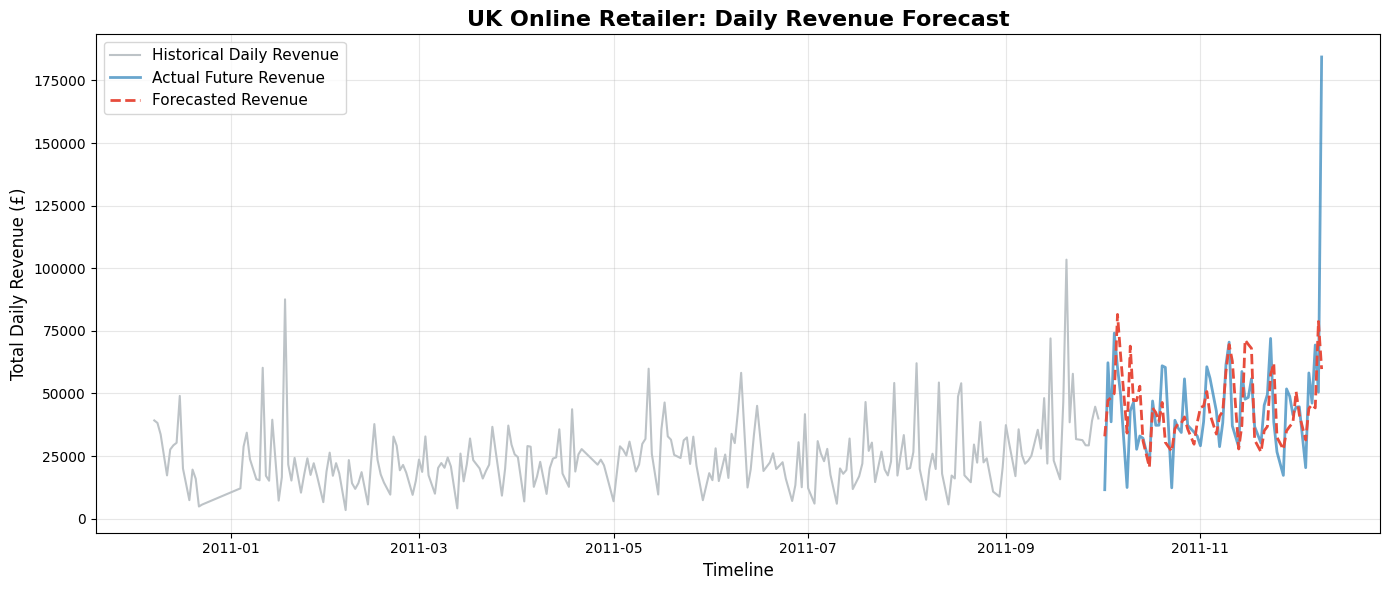

In [5]:
plt.figure(figsize=(14, 6))

# Plot historical actuals
plt.plot(dates_train, y_train, label='Historical Daily Revenue', color='#bdc3c7')

# Plot actual vs predicted for the test period
plt.plot(dates_test, y_test, label='Actual Future Revenue', color='#2980b9', alpha=0.7, linewidth=2)
plt.plot(dates_test, predictions, label='Forecasted Revenue', color='#e74c3c', linestyle='dashed', linewidth=2)

# Business-friendly formatting
plt.title('UK Online Retailer: Daily Revenue Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Daily Revenue (£)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the image so you can download it from Colab
plt.savefig('uci_revenue_forecast.png', dpi=300)
plt.show()